In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
df = pd.read_csv('UCI_Heart_Disease_Dataset_Combined.csv')

In [6]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,HeartDisease
0,40,1,1,140,289,0,0,172,0,0.0,0
1,49,0,2,160,180,0,0,156,0,1.0,1
2,37,1,1,130,283,0,1,98,0,0.0,0
3,48,0,3,138,214,0,0,108,1,1.5,1
4,54,1,2,150,195,0,0,122,0,0.0,0


In [8]:
df.shape

(2943, 11)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2943 entries, 0 to 2942
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             2943 non-null   int64  
 1   Sex             2943 non-null   int64  
 2   ChestPainType   2943 non-null   int64  
 3   RestingBP       2943 non-null   int64  
 4   Cholesterol     2943 non-null   int64  
 5   FastingBS       2943 non-null   int64  
 6   RestingECG      2943 non-null   int64  
 7   MaxHR           2943 non-null   int64  
 8   ExerciseAngina  2943 non-null   int64  
 9   Oldpeak         2943 non-null   float64
 10  HeartDisease    2943 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 253.0 KB


In [14]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

## Train - Test split

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

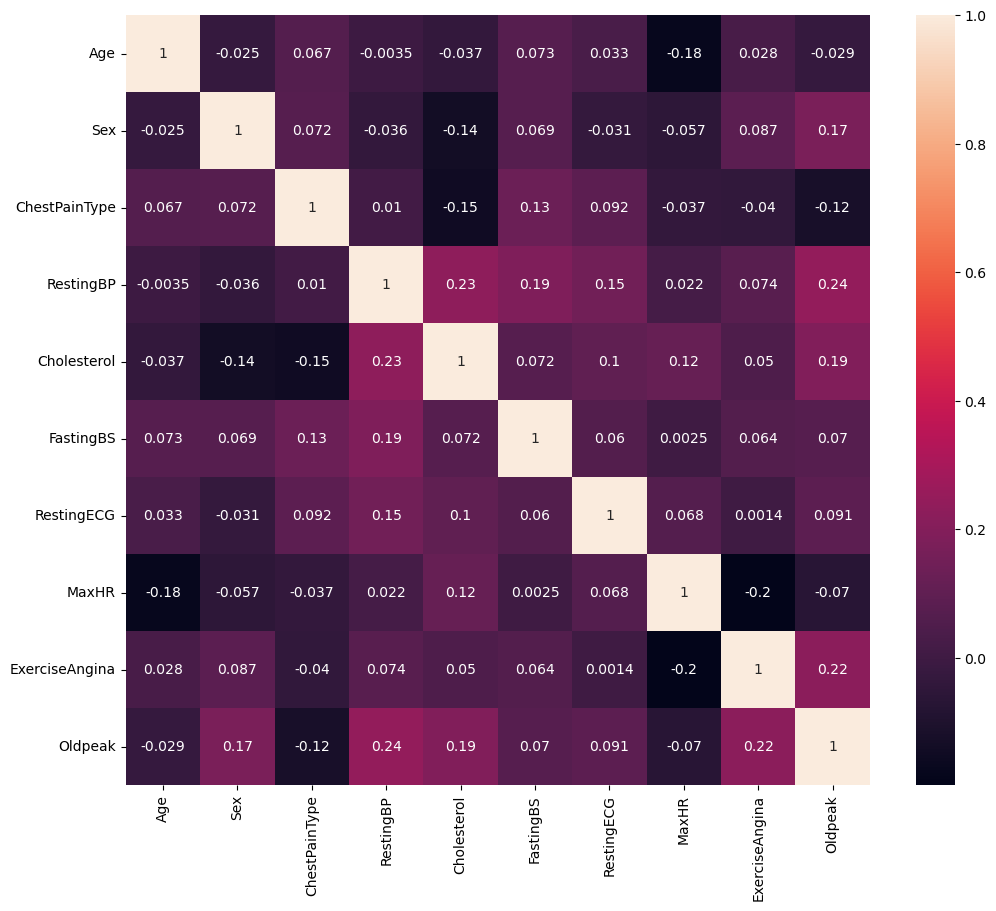

In [19]:
plt.figure(figsize=(12,10))
corr = X_train.corr()
sns.heatmap(corr,annot=True)
plt.show()

## Model Building

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
models={
    "Logisitic Regression":LogisticRegression(),
    "SVC(Linear)":SVC(kernel='linear'),
    "SVC(rbf)":SVC(kernel='rbf'),
    "SVC(poly)":SVC(kernel='poly'),
    "SVC(sigmoid)":SVC(kernel='sigmoid'),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "Gradient Boost":GradientBoostingClassifier(),
    "Adaboost":AdaBoostClassifier(),
    "XgBoost":XGBClassifier()
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
    
    print('----------------------------------')

    print("Confusion matrix")
    print(confusion_matrix(y_test,y_test_pred))
    
    print('----------------------------------')
    print("Classification report")
    print(classification_report(y_test,y_test_pred))

    
    print('='*35)
    print('\n')

Logisitic Regression
Model performance for Training set
- Accuracy: 0.7379
- F1 score: 0.7371
- Precision: 0.7487
- Recall: 0.7842
- Roc Auc Score: 0.7331
----------------------------------
Model performance for Test set
- Accuracy: 0.7402
- F1 score: 0.7386
- Precision: 0.7464
- Recall: 0.8037
- Roc Auc Score: 0.7326
----------------------------------
Confusion matrix
[[174  89]
 [ 64 262]]
----------------------------------
Classification report
              precision    recall  f1-score   support

           0       0.73      0.66      0.69       263
           1       0.75      0.80      0.77       326

    accuracy                           0.74       589
   macro avg       0.74      0.73      0.73       589
weighted avg       0.74      0.74      0.74       589



SVC(Linear)
Model performance for Training set
- Accuracy: 0.7336
- F1 score: 0.7325
- Precision: 0.7421
- Recall: 0.7865
- Roc Auc Score: 0.7281
----------------------------------
Model performance for Test set
- Accur

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Adaboost
Model performance for Training set
- Accuracy: 0.7778
- F1 score: 0.7774
- Precision: 0.7878
- Recall: 0.8129
- Roc Auc Score: 0.7742
----------------------------------
Model performance for Test set
- Accuracy: 0.7606
- F1 score: 0.7597
- Precision: 0.7697
- Recall: 0.8098
- Roc Auc Score: 0.7547
----------------------------------
Confusion matrix
[[184  79]
 [ 62 264]]
----------------------------------
Classification report
              precision    recall  f1-score   support

           0       0.75      0.70      0.72       263
           1       0.77      0.81      0.79       326

    accuracy                           0.76       589
   macro avg       0.76      0.75      0.76       589
weighted avg       0.76      0.76      0.76       589



XgBoost
Model performance for Training set
- Accuracy: 0.9970
- F1 score: 0.9970
- Precision: 0.9984
- Recall: 0.9961
- Roc Auc Score: 0.9971
----------------------------------
Model performance for Test set
- Accuracy: 0.8676
- F1

## Hyper parameter tuning on Random Forest 

In [26]:
rf_params = {"max_depth": [5, 8, 9, None, 10,11,12],
             "max_features": [5, 7, "auto", 8,12],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}

In [30]:
from sklearn.model_selection import GridSearchCV
grid_rf = GridSearchCV(RandomForestClassifier(),param_grid=rf_params,cv=5,verbose=3,refit=True)

In [32]:
grid_rf.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 560 candidates, totalling 2800 fits
[CV 1/5] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=100;, score=0.796 total time=   0.3s
[CV 2/5] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=100;, score=0.775 total time=   0.3s
[CV 3/5] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=100;, score=0.786 total time=   0.3s
[CV 4/5] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=100;, score=0.796 total time=   0.2s
[CV 5/5] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=100;, score=0.743 total time=   0.3s
[CV 1/5] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=200;, score=0.798 total time=   0.6s
[CV 2/5] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=200;, score=0.786 total time=   0.6s
[CV 3/5] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=200;, score=0.783 total time=   0.6s
[CV 4/5] END max_depth=5, max_fe

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
560 fits failed out of a total of 2800.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
560 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "C:\ProgramData\anaconda3\Lib\site-packa

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 8, 9, None, 10, 11, 12],
                         'max_features': [5, 7, 'auto', 8, 12],
                         'min_samples_split': [2, 8, 15, 20],
                         'n_estimators': [100, 200, 500, 1000]},
             verbose=3)

In [33]:
grid_rf.best_params_

{'max_depth': None,
 'max_features': 5,
 'min_samples_split': 2,
 'n_estimators': 500}

In [34]:
grid_rf.best_score_

0.8844504675430276

In [35]:
y_pred = grid_rf.predict(X_test_scaled)
print(confusion_matrix(y_pred,y_test))
print(accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

[[209  15]
 [ 54 311]]
0.8828522920203735
              precision    recall  f1-score   support

           0       0.79      0.93      0.86       224
           1       0.95      0.85      0.90       365

    accuracy                           0.88       589
   macro avg       0.87      0.89      0.88       589
weighted avg       0.89      0.88      0.88       589



In [52]:
model = RandomForestClassifier()
model.fit(X_train_scaled,y_train)

y_pred = model.predict(X_test_scaled)
print(confusion_matrix(y_pred,y_test))
print(accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

[[208  16]
 [ 55 310]]
0.8794567062818336
              precision    recall  f1-score   support

           0       0.79      0.93      0.85       224
           1       0.95      0.85      0.90       365

    accuracy                           0.88       589
   macro avg       0.87      0.89      0.88       589
weighted avg       0.89      0.88      0.88       589



## Hyper parameter tunning on XGBoost

In [36]:
xg_params = {"learning_rate": [0.1, 0.01],
                  "max_depth": [5, 8, 12, 20, 30],
                  "n_estimators": [100, 200, 300],
                  "colsample_bytree": [0.5, 0.8, 1, 0.3, 0.4]}

In [42]:
grid_xg = GridSearchCV(XGBClassifier(),param_grid=xg_params,cv=5,verbose=3,refit=True)


In [44]:
grid_xg.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits
[CV 1/5] END colsample_bytree=0.5, learning_rate=0.1, max_depth=5, n_estimators=100;, score=0.837 total time=   0.0s
[CV 2/5] END colsample_bytree=0.5, learning_rate=0.1, max_depth=5, n_estimators=100;, score=0.845 total time=   0.0s
[CV 3/5] END colsample_bytree=0.5, learning_rate=0.1, max_depth=5, n_estimators=100;, score=0.834 total time=   0.0s
[CV 4/5] END colsample_bytree=0.5, learning_rate=0.1, max_depth=5, n_estimators=100;, score=0.824 total time=   0.0s
[CV 5/5] END colsample_bytree=0.5, learning_rate=0.1, max_depth=5, n_estimators=100;, score=0.809 total time=   0.0s
[CV 1/5] END colsample_bytree=0.5, learning_rate=0.1, max_depth=5, n_estimators=200;, score=0.845 total time=   0.0s
[CV 2/5] END colsample_bytree=0.5, learning_rate=0.1, max_depth=5, n_estimators=200;, score=0.873 total time=   0.0s
[CV 3/5] END colsample_bytree=0.5, learning_rate=0.1, max_depth=5, n_estimators=200;, score=0.849 total time=   0.0s
[

C:\ProgramData\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'colsample_bytree': [0.5, 0.8, 1, 0.3, 0.4],
                         'learning_rate': [0.1, 0.01],
                         'max_depth': [5, 8, 12, 20, 30],
                         'n_estimators': [100, 200, 300]},
             verbose=3)

In [45]:
grid_xg.best_params_

{'colsample_bytree': 1,
 'learning_rate': 0.1,
 'max_depth': 20,
 'n_estimators': 100}

In [46]:
grid_xg.best_score_

0.8823282287572842

In [47]:
y_pred = grid_xg.predict(X_test_scaled)
print(confusion_matrix(y_pred,y_test))
print(accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

[[213  26]
 [ 50 300]]
0.8709677419354839
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       239
           1       0.92      0.86      0.89       350

    accuracy                           0.87       589
   macro avg       0.87      0.87      0.87       589
weighted avg       0.88      0.87      0.87       589



## Saving the model

In [54]:
import pickle
pickle.dump(grid_rf.best_estimator_,open('heart_disease_model.pkl','wb'))
pickle.dump(scaler,open('heart_disease_scaler.pkl','wb'))